# Turbulence Intensity Analysis for ADCP Data

This notebook computes turbulence intensity (TI) from ADCP velocity records using both fluctuation-based and Doppler-noise-corrected approaches. Calculations are resolved by tidal phase (EBB/FLOOD) and include depth-dependent and depth-averaged perspectives.

## Analysis Workflow
- Build fluctuation signal with rolling ensemble mean: $u' = u - \overline{u}_{window}$
- Compute phase-wise TI from fluctuations: $TI(\%) = 100\,\sigma(u')/\overline{U}_{used}$
- Visualize depth-dependent fluctuation TI profiles for EBB and FLOOD
- Apply Doppler-noise correction to variance: $\sigma_{turb} = \sqrt{\max(\sigma_{measured}^2 - \sigma_{noise}^2, 0)}$
- Report both raw and noise-corrected TI metrics
    
## Inputs and Outputs
- Input files: `depth_dependent_velocity_components.csv`, `depthAvg_ADCPdata_labeled.csv`
- Key controls: `ENSEMBLE_WINDOW`, `DOPPLER_NOISE_STD_MS`
- Output tables are printed in-cell and can be exported from analysis cells as needed

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Fluctuation-Based TI by Phase

This section computes turbulence intensity from along-channel fluctuations using a rolling ensemble mean.

Method:
1. Build fluctuations: $u' = u - \overline{u}_{window}$
2. Compute $\sigma(u')$ for each phase
3. Compute TI as $100\,\sigma(u')/\overline{U}_{used}$

Outputs include depth-dependent and depth-averaged phase-wise TI (EBB/FLOOD).

In [31]:
# Fluctuation-based TI using ensemble mean
# u' = u_along - <u_along>_window, then TI = 100 * std(u') / mean(speed_used)
ENSEMBLE_WINDOW = '60min'

# ---------- Depth-dependent ----------
df_fluc_dep = pd.read_csv('depth_dependent_velocity_components.csv')
df_fluc_dep['DateTime'] = pd.to_datetime(df_fluc_dep['DateTime'], errors='coerce')
for c in ['u_along_ms', 'u_across_ms', 'depth_m', 'bin_number']:
    df_fluc_dep[c] = pd.to_numeric(df_fluc_dep[c], errors='coerce')

df_fluc_dep['phase'] = df_fluc_dep['phase'].astype(str).str.upper().str.strip()
df_fluc_dep = df_fluc_dep[df_fluc_dep['phase'].isin(['EBB', 'FLOOD'])].copy()
df_fluc_dep['speed_ms'] = np.sqrt(df_fluc_dep['u_along_ms']**2 + df_fluc_dep['u_across_ms']**2)

df_fluc_dep = df_fluc_dep.sort_values(['bin_number', 'DateTime']).copy()
df_fluc_dep['u_along_mean_window'] = np.nan
df_fluc_dep['speed_used'] = np.nan

for _, idx in df_fluc_dep.groupby('bin_number').groups.items():
    sub = df_fluc_dep.loc[idx].sort_values('DateTime')
    u_mean = (
        sub.set_index('DateTime')['u_along_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    s_mean = (
        sub.set_index('DateTime')['speed_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    df_fluc_dep.loc[sub.index, 'u_along_mean_window'] = u_mean
    df_fluc_dep.loc[sub.index, 'speed_used'] = s_mean

df_fluc_dep['u_prime'] = df_fluc_dep['u_along_ms'] - df_fluc_dep['u_along_mean_window']

def calc_ti_fluc_dep(group):
    std_u_prime = group['u_prime'].std(ddof=1)
    speed_used_mean = group['speed_used'].mean()
    ti_pct = np.nan if (pd.isna(std_u_prime) or pd.isna(speed_used_mean) or speed_used_mean == 0) else 100.0 * std_u_prime / speed_used_mean
    return pd.Series({
        'n_samples': len(group),
        'mean_speed_ms_used': speed_used_mean,
        'std_u_prime_ms': std_u_prime,
        'TI_from_fluct_percent': ti_pct
    })

ti_fluc_dep_by_phase = (
    df_fluc_dep.groupby('phase', as_index=False)
    .apply(calc_ti_fluc_dep)
    .reset_index(drop=True)
    .sort_values('phase')
)

print(f"Depth-dependent fluctuation TI ({ENSEMBLE_WINDOW} ensemble):")
print(ti_fluc_dep_by_phase)

# ---------- Depth-averaged ----------
df_fluc_avg = pd.read_csv('depthAvg_ADCPdata_labeled.csv')
df_fluc_avg['Time'] = pd.to_datetime(df_fluc_avg['Date & Time.2'], format='mixed', errors='coerce')
for c in ['Eas', 'Nor', 'u_along_overall']:
    df_fluc_avg[c] = pd.to_numeric(df_fluc_avg[c], errors='coerce')

df_fluc_avg['phase'] = df_fluc_avg['phase'].astype(str).str.upper().str.strip()
df_fluc_avg = df_fluc_avg[df_fluc_avg['phase'].isin(['EBB', 'FLOOD'])].copy()
df_fluc_avg['speed_ms'] = np.sqrt(df_fluc_avg['Eas']**2 + df_fluc_avg['Nor']**2)

df_fluc_avg = df_fluc_avg.sort_values('Time').copy()
df_fluc_avg['u_along_mean_window'] = (
    df_fluc_avg.rolling(ENSEMBLE_WINDOW, on='Time', min_periods=1)['u_along_overall']
    .mean()
    .to_numpy()
)
df_fluc_avg['speed_used'] = (
    df_fluc_avg.rolling(ENSEMBLE_WINDOW, on='Time', min_periods=1)['speed_ms']
    .mean()
    .to_numpy()
)
df_fluc_avg['u_prime'] = df_fluc_avg['u_along_overall'] - df_fluc_avg['u_along_mean_window']

def calc_ti_fluc_avg(group):
    std_u_prime = group['u_prime'].std(ddof=1)
    speed_used_mean = group['speed_used'].mean()
    ti_pct = np.nan if (pd.isna(std_u_prime) or pd.isna(speed_used_mean) or speed_used_mean == 0) else 100.0 * std_u_prime / speed_used_mean
    return pd.Series({
        'n_samples': len(group),
        'mean_speed_ms_used': speed_used_mean,
        'std_u_prime_ms': std_u_prime,
        'TI_from_fluct_percent': ti_pct
    })

ti_fluc_avg_by_phase = (
    df_fluc_avg.groupby('phase', as_index=False)
    .apply(calc_ti_fluc_avg)
    .reset_index(drop=True)
    .sort_values('phase')
)

print(f"\nDepth-avg fluctuation TI ({ENSEMBLE_WINDOW} ensemble):")
print(ti_fluc_avg_by_phase)

Depth-dependent fluctuation TI (60min ensemble):
   phase  n_samples  mean_speed_ms_used  std_u_prime_ms  TI_from_fluct_percent
0    EBB   351604.0            0.708725        0.173225              24.441815
1  FLOOD   355476.0            0.743447        0.166732              22.426884

Depth-avg fluctuation TI (60min ensemble):
   phase  n_samples  mean_speed_ms_used  std_u_prime_ms  TI_from_fluct_percent
0    EBB     6267.0            0.848606        0.117499              13.846101
1  FLOOD     6483.0            0.869053        0.118243              13.605916


## Depth-Dependent Fluctuation TI Visualization

This section visualizes depth-dependent fluctuation TI profiles for EBB and FLOOD.

The plot compares how TI changes with depth, using the configured ensemble window and fluctuation-based TI definition.

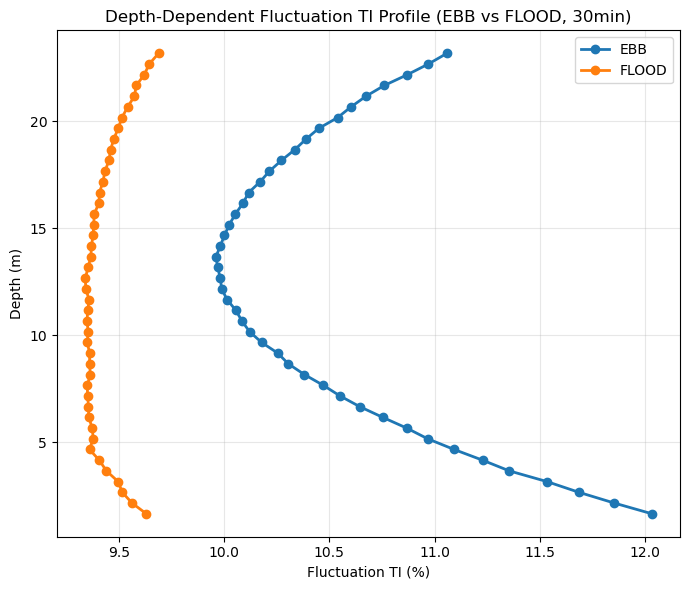

In [32]:
# Plot depth-dependent fluctuation TI profile for EBB and FLOOD (30-min ensemble)
# This cell is runnable on its own.

ENSEMBLE_WINDOW = '30min'

df_plot = pd.read_csv('depth_dependent_velocity_components.csv')
df_plot['DateTime'] = pd.to_datetime(df_plot['DateTime'], errors='coerce')
for c in ['u_along_ms', 'u_across_ms', 'depth_m', 'bin_number']:
    df_plot[c] = pd.to_numeric(df_plot[c], errors='coerce')

df_plot['phase'] = df_plot['phase'].astype(str).str.upper().str.strip()
df_plot = df_plot[df_plot['phase'].isin(['EBB', 'FLOOD'])].copy()
df_plot['speed_ms'] = np.sqrt(df_plot['u_along_ms']**2 + df_plot['u_across_ms']**2)

df_plot = df_plot.sort_values(['bin_number', 'DateTime']).copy()
df_plot['u_along_mean_window'] = np.nan
df_plot['speed_used'] = np.nan

for _, idx in df_plot.groupby('bin_number').groups.items():
    sub = df_plot.loc[idx].sort_values('DateTime')
    u_mean = (
        sub.set_index('DateTime')['u_along_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    s_mean = (
        sub.set_index('DateTime')['speed_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    df_plot.loc[sub.index, 'u_along_mean_window'] = u_mean
    df_plot.loc[sub.index, 'speed_used'] = s_mean

df_plot['u_prime'] = df_plot['u_along_ms'] - df_plot['u_along_mean_window']

def _calc_ti_fluct_depth(group):
    std_u_prime = group['u_prime'].std(ddof=1)
    speed_used_mean = group['speed_used'].mean()
    ti_pct = np.nan if (pd.isna(std_u_prime) or pd.isna(speed_used_mean) or speed_used_mean == 0) else 100.0 * std_u_prime / speed_used_mean
    return pd.Series({
        'n_samples': len(group),
        'mean_speed_ms_used': speed_used_mean,
        'std_u_prime_ms': std_u_prime,
        'TI_from_fluct_percent': ti_pct
    })

ti_fluc_by_bin_phase = (
    df_plot.groupby(['bin_number', 'depth_m', 'phase'], as_index=False)
    .apply(_calc_ti_fluct_depth)
    .reset_index(drop=True)
    .sort_values(['bin_number', 'phase'])
)

ti_fluc_ebb_plot = ti_fluc_by_bin_phase[ti_fluc_by_bin_phase['phase'] == 'EBB'].sort_values('depth_m')
ti_fluc_flood_plot = ti_fluc_by_bin_phase[ti_fluc_by_bin_phase['phase'] == 'FLOOD'].sort_values('depth_m')

plt.figure(figsize=(7, 6))
plt.plot(ti_fluc_ebb_plot['TI_from_fluct_percent'], ti_fluc_ebb_plot['depth_m'], marker='o', linewidth=2, label='EBB')
plt.plot(ti_fluc_flood_plot['TI_from_fluct_percent'], ti_fluc_flood_plot['depth_m'], marker='o', linewidth=2, label='FLOOD')
plt.xlabel('Fluctuation TI (%)')
plt.ylabel('Depth (m)')
plt.title(f'Depth-Dependent Fluctuation TI Profile (EBB vs FLOOD, {ENSEMBLE_WINDOW})')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Doppler-Noise-Corrected TI

This section estimates and removes Doppler noise contribution from measured fluctuation variance.

Correction used:
$\sigma_{turb} = \sqrt{\max(\sigma_{measured}^2 - \sigma_{noise}^2, 0)}$

The configured Doppler noise level (`DOPPLER_NOISE_STD_MS`) is based on empirical ranges reported in the ADCP turbulence literature, specifically: https://doi.org/10.1109/JOE.2012.2191656

Reported outputs show both raw TI and Doppler-noise-corrected TI for depth-dependent and depth-averaged data.

In [34]:
# TI with Doppler-noise correction (variance subtraction)
# sigma_turb = sqrt(max(sigma_measured^2 - sigma_noise^2, 0))
# TI_noise_corrected(%) = 100 * sigma_turb / mean(speed_used)

ENSEMBLE_WINDOW = '60min'
DOPPLER_NOISE_STD_MS = 0.14  # adjust based on instrument specs/QC

# ---------- Depth-dependent ----------
df_dn_dep = pd.read_csv('depth_dependent_velocity_components.csv')
df_dn_dep['DateTime'] = pd.to_datetime(df_dn_dep['DateTime'], errors='coerce')
for c in ['u_along_ms', 'u_across_ms', 'depth_m', 'bin_number']:
    df_dn_dep[c] = pd.to_numeric(df_dn_dep[c], errors='coerce')

df_dn_dep['phase'] = df_dn_dep['phase'].astype(str).str.upper().str.strip()
df_dn_dep = df_dn_dep[df_dn_dep['phase'].isin(['EBB', 'FLOOD'])].copy()
df_dn_dep['speed_ms'] = np.sqrt(df_dn_dep['u_along_ms']**2 + df_dn_dep['u_across_ms']**2)

df_dn_dep = df_dn_dep.sort_values(['bin_number', 'DateTime']).copy()
df_dn_dep['u_along_mean_window'] = np.nan
df_dn_dep['speed_used'] = np.nan
for _, idx in df_dn_dep.groupby('bin_number').groups.items():
    sub = df_dn_dep.loc[idx].sort_values('DateTime')
    u_mean = (
        sub.set_index('DateTime')['u_along_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    s_mean = (
        sub.set_index('DateTime')['speed_ms']
        .rolling(ENSEMBLE_WINDOW, min_periods=1)
        .mean()
        .to_numpy()
    )
    df_dn_dep.loc[sub.index, 'u_along_mean_window'] = u_mean
    df_dn_dep.loc[sub.index, 'speed_used'] = s_mean

df_dn_dep['u_prime'] = df_dn_dep['u_along_ms'] - df_dn_dep['u_along_mean_window']

def calc_ti_doppler_corrected(group):
    sigma_measured = group['u_prime'].std(ddof=1)
    sigma_turb = np.sqrt(max(sigma_measured**2 - DOPPLER_NOISE_STD_MS**2, 0.0)) if pd.notna(sigma_measured) else np.nan
    speed_used_mean = group['speed_used'].mean()
    ti_raw = np.nan if (pd.isna(sigma_measured) or pd.isna(speed_used_mean) or speed_used_mean == 0) else 100.0 * sigma_measured / speed_used_mean
    ti_corr = np.nan if (pd.isna(sigma_turb) or pd.isna(speed_used_mean) or speed_used_mean == 0) else 100.0 * sigma_turb / speed_used_mean
    return pd.Series({
        'n_samples': len(group),
        'mean_speed_ms_used': speed_used_mean,
        'sigma_u_prime_measured_ms': sigma_measured,
        'sigma_u_prime_turb_ms': sigma_turb,
        'TI_raw_percent': ti_raw,
        'TI_doppler_corrected_percent': ti_corr
    })

ti_dn_dep_phase = (
    df_dn_dep.groupby('phase', as_index=False)
    .apply(calc_ti_doppler_corrected)
    .reset_index(drop=True)
    .sort_values('phase')
)

ti_dn_dep_bin_phase = (
    df_dn_dep.groupby(['bin_number', 'depth_m', 'phase'], as_index=False)
    .apply(calc_ti_doppler_corrected)
    .reset_index(drop=True)
    .sort_values(['bin_number', 'phase'])
)

print(f'Depth-dependent TI with Doppler-noise correction (noise std = {DOPPLER_NOISE_STD_MS:.3f} m/s):')
print(ti_dn_dep_phase)

# ---------- Depth-averaged ----------
df_dn_avg = pd.read_csv('depthAvg_ADCPdata_labeled.csv')
df_dn_avg['Time'] = pd.to_datetime(df_dn_avg['Date & Time.2'], format='mixed', errors='coerce')
for c in ['Eas', 'Nor', 'u_along_overall']:
    df_dn_avg[c] = pd.to_numeric(df_dn_avg[c], errors='coerce')

df_dn_avg['phase'] = df_dn_avg['phase'].astype(str).str.upper().str.strip()
df_dn_avg = df_dn_avg[df_dn_avg['phase'].isin(['EBB', 'FLOOD'])].copy()
df_dn_avg['speed_ms'] = np.sqrt(df_dn_avg['Eas']**2 + df_dn_avg['Nor']**2)

df_dn_avg = df_dn_avg.sort_values('Time').copy()
df_dn_avg['u_along_mean_window'] = (
    df_dn_avg.rolling(ENSEMBLE_WINDOW, on='Time', min_periods=1)['u_along_overall']
    .mean()
    .to_numpy()
)
df_dn_avg['speed_used'] = (
    df_dn_avg.rolling(ENSEMBLE_WINDOW, on='Time', min_periods=1)['speed_ms']
    .mean()
    .to_numpy()
)
df_dn_avg['u_prime'] = df_dn_avg['u_along_overall'] - df_dn_avg['u_along_mean_window']

ti_dn_avg_phase = (
    df_dn_avg.groupby('phase', as_index=False)
    .apply(calc_ti_doppler_corrected)
    .reset_index(drop=True)
    .sort_values('phase')
)

print(f'\nDepth-avg TI with Doppler-noise correction (noise std = {DOPPLER_NOISE_STD_MS:.3f} m/s):')
print(ti_dn_avg_phase)

Depth-dependent TI with Doppler-noise correction (noise std = 0.140 m/s):
   phase  n_samples  mean_speed_ms_used  sigma_u_prime_measured_ms  \
0    EBB   351604.0            0.708725                   0.173225   
1  FLOOD   355476.0            0.743447                   0.166732   

   sigma_u_prime_turb_ms  TI_raw_percent  TI_doppler_corrected_percent  
0               0.102015       24.441815                     14.394111  
1               0.090552       22.426884                     12.179951  

Depth-avg TI with Doppler-noise correction (noise std = 0.140 m/s):
   phase  n_samples  mean_speed_ms_used  sigma_u_prime_measured_ms  \
0    EBB     6267.0            0.848606                   0.117499   
1  FLOOD     6483.0            0.869053                   0.118243   

   sigma_u_prime_turb_ms  TI_raw_percent  TI_doppler_corrected_percent  
0                    0.0       13.846101                           0.0  
1                    0.0       13.605916                           0.0